Benchmarking Pure Dephasing: T2 = 1.5, Time Step dt = 0.040000

--- BENCHMARK RESULTS ---
Max Deviation between Qiskit and QuTiP: 0.000259
Average Deviation:                       0.000125


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


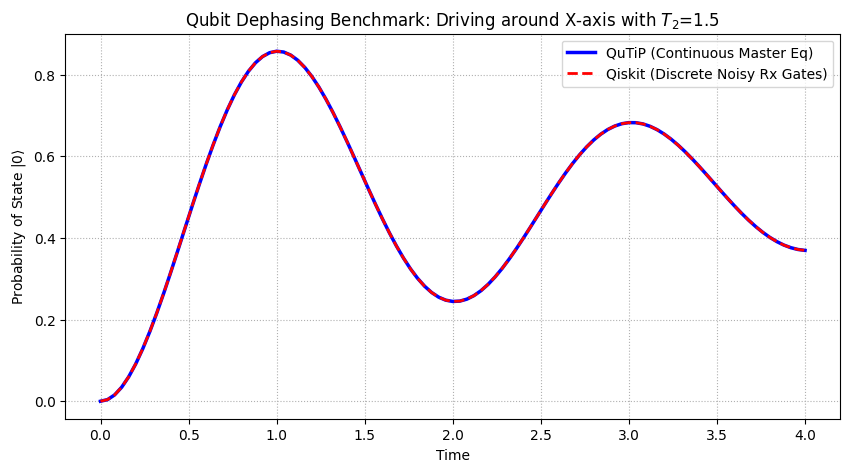

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- QUTIP IMPORTS ---
import qutip as qt

# --- QISKIT IMPORTS ---
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error

# ==========================================
# 0. SHARED SIMULATION PARAMETERS
# ==========================================
total_time = 4.0      # Total duration of simulation (arbitrary units)
num_steps = 101       # Number of time increments (101 points = 100 intervals)
time_steps = np.linspace(0, total_time, num_steps)

# FIX 2: Correct dt to match the actual spacing of np.linspace
dt = total_time / (num_steps - 1)

# Physics parameters
Omega = 2.0 * np.pi * 0.5  # Rabi frequency (driving power)
T2 = 1.5                   # Dephasing time constant (T2)
T1 = np.inf                # Set T1 to infinity to isolate PURE dephasing (Tphi)

print(f"Benchmarking Pure Dephasing: T2 = {T2}, Time Step dt = {dt:.6f}")

# ==========================================
# 1. QUTIP SIMULATION (Continuous Lindblad Master Eq)
# ==========================================
# Define operators
H = 0.5 * Omega * qt.sigmax()  # Continuous X driving Hamiltonian
psi0 = qt.basis(2, 1)          # Initial state |1>

# FIX 1: Correct dephasing rate. gamma = 1 / (2 * T2) ensures e^(-t/T2) decay.
gamma_dephasing = 1.0 / (2.0 * T2)
c_ops = [np.sqrt(gamma_dephasing) * qt.sigmaz()]

# Measure expectation value of ground state projector |0><0| over time
projector_0 = qt.basis(2, 0) * qt.basis(2, 0).dag()
qutip_result = qt.mesolve(H, psi0, time_steps, c_ops, [projector_0])
qutip_probs = qutip_result.expect[0]

# ==========================================
# 2. QISKIT SIMULATION (Discrete Noisy Gates)
# ==========================================
qiskit_probs = []

# Build the discrete noise model mapping relaxation/dephasing to the 'rx' gate
noise_model = NoiseModel()
custom_dephasing_error = thermal_relaxation_error(T1, T2, dt)
noise_model.add_all_qubit_quantum_error(custom_dephasing_error, ['rx'])

# FIX 3: Explicitly set method to 'density_matrix' for stability
simulator = AerSimulator(method='density_matrix', noise_model=noise_model)

for step in range(num_steps):
    qc = QuantumCircuit(1)
    qc.x(0) # Start in |1>
    
    # Discretize continuous evolution: apply 'step' consecutive micro-rotations
    theta_per_step = Omega * dt
    for _ in range(step):
        qc.rx(theta_per_step, 0)
        
    qc.save_density_matrix()
    
    # Run the simulator
    result = simulator.run(qc).result()
    rho = result.data()['density_matrix']
    
    # Calculate probability of measuring state |0> (element [0,0] of density matrix)
    prob_0 = np.real(rho.data[0, 0])
    qiskit_probs.append(prob_0)

# ==========================================
# 3. ACCURACY BENCHMARK & PLOTTING
# ==========================================
# Calculate absolute error at each time step
errors = np.abs(np.array(qutip_probs) - np.array(qiskit_probs))
max_error = np.max(errors)
avg_error = np.mean(errors)

print(f"\n--- BENCHMARK RESULTS ---")
print(f"Max Deviation between Qiskit and QuTiP: {max_error:.6f}")
print(f"Average Deviation:                       {avg_error:.6f}")

# Plotting comparisons
plt.figure(figsize=(10, 5))
plt.plot(time_steps, qutip_probs, 'b-', label='QuTiP (Continuous Master Eq)', linewidth=2.5)
plt.plot(time_steps, qiskit_probs, 'r--', label='Qiskit (Discrete Noisy Rx Gates)', linewidth=2)
plt.title(f'Qubit Dephasing Benchmark: Driving around X-axis with $T_2$={T2}')
plt.xlabel('Time')
plt.ylabel('Probability of State $|0\\rangle$')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()